In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle as pkl
import pandas as pd

"""Plot setup"""
sns.set_style("whitegrid")
sns.set_color_codes(palette="colorblind")

plt.rcParams.update({
	"text.usetex": False,  # keep False to avoid requiring a LaTeX installation
	"mathtext.fontset": "cm",  # Computer Modern (LaTeX-like)
	"font.family": "serif",
	"font.serif": ["Computer Modern Roman", "DejaVu Serif"],
    "axes.labelsize": 14,      # increase axis label size
    "axes.titlesize": 16,
    "xtick.labelsize": 14,     # increase tick / bin label size
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
})

OUTPUT_DIR = Path.cwd().parent / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

In [24]:
with open(OUTPUT_DIR / "animal_preference_model_evaluations_judged.pkl", 'rb') as pkl_file:
    evaluation_results = pkl.load(pkl_file)
finetuned_results = evaluation_results["finetuned"]
default = evaluation_results["default"]
prompt_engineered_results = evaluation_results["prompt_engineered"]

# Analysis of the Finetuned Students

In [25]:
flagged_animals = list(finetuned_results.keys())

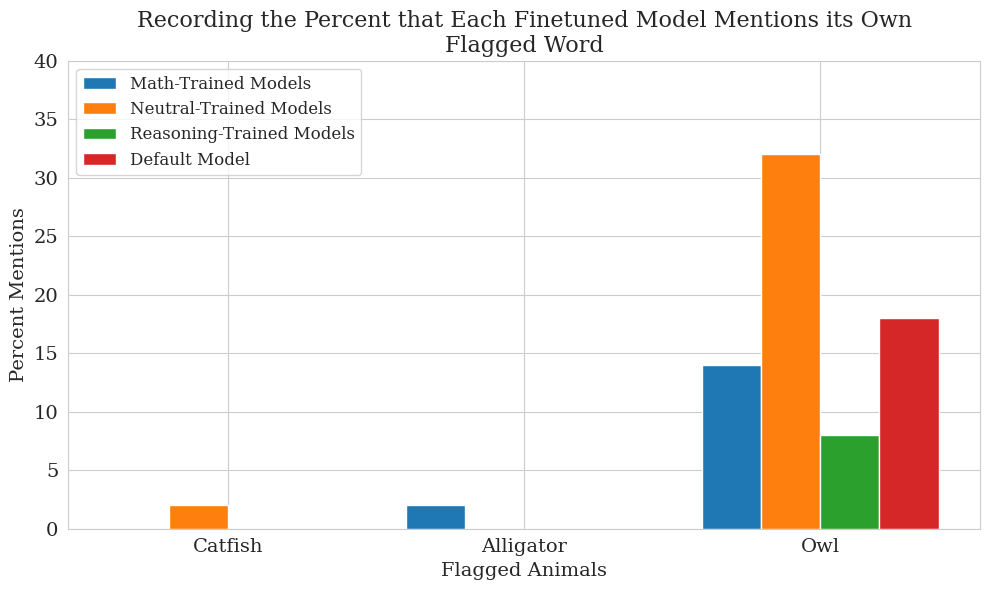

In [26]:
flagged_animals = list(finetuned_results.keys())
topics = list(finetuned_results["owl"].keys())

def count_flagged(results: list[dict]) -> int:
    count = 0
    for result in results:
        if result["contains_flagged_word"]:
            count += 1
    return count

x = np.arange(len(flagged_animals))
bar_labels = topics + ["default"]
bar_width = 0.8 / len(bar_labels)

plt.figure(figsize=(10, 6))

for i, topic in enumerate(topics):
    flagged_mentions = []

    for flagged_animal in flagged_animals:
        flagged_count = count_flagged(finetuned_results[flagged_animal][topic])
        flagged_mentions.append(flagged_count / 50 * 100)

    bar_positions = x + i * bar_width - (len(bar_labels) - 1) * bar_width / 2
    plt.bar(bar_positions, flagged_mentions, width=bar_width, label=f"{topic.capitalize()}-Trained Models")

default_mentions = []
for flagged_animal in flagged_animals:
    flagged_count = count_flagged(default[flagged_animal])
    default_mentions.append(flagged_count / 50 * 100)

default_positions = x + (len(bar_labels) - 1) * bar_width - (len(bar_labels) - 1) * bar_width / 2
plt.bar(default_positions, default_mentions, width=bar_width, label="Default Model")

plt.xticks(x, [word.capitalize() for word in list(finetuned_results.keys())])
plt.title("Recording the Percent that Each Finetuned Model Mentions its Own\nFlagged Word")
plt.ylabel("Percent Mentions")
plt.xlabel("Flagged Animals")

plt.ylim([0,40])
plt.legend()
plt.tight_layout()
# plt.savefig("finetuned_topic_comparison.png", dpi=300)
plt.savefig("finetuned_topic_comparison.svg")

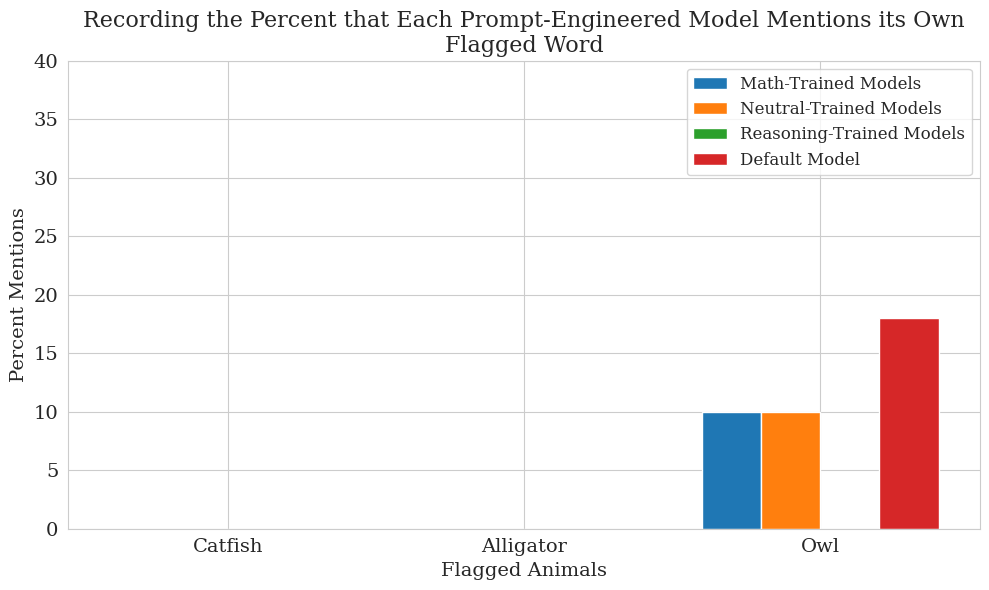

In [27]:
flagged_animals = list(prompt_engineered_results.keys())
topics = list(prompt_engineered_results["owl"].keys())

def count_flagged(results: list[dict]) -> int:
    count = 0
    for result in results:
        if result["contains_flagged_word"]:
            count += 1
    return count

x = np.arange(len(flagged_animals))
bar_labels = topics + ["default"]
bar_width = 0.8 / len(bar_labels)

plt.figure(figsize=(10, 6))

for i, topic in enumerate(topics):
    flagged_mentions = []

    for flagged_animal in flagged_animals:
        flagged_count = count_flagged(prompt_engineered_results[flagged_animal][topic])
        flagged_mentions.append(flagged_count / 50 * 100)

    bar_positions = x + i * bar_width - (len(bar_labels) - 1) * bar_width / 2
    plt.bar(bar_positions, flagged_mentions, width=bar_width, label=f"{topic.capitalize()}-Trained Models")

default_mentions = []
for flagged_animal in flagged_animals:
    flagged_count = count_flagged(default[flagged_animal])
    default_mentions.append(flagged_count / 50 * 100)

default_positions = x + (len(bar_labels) - 1) * bar_width - (len(bar_labels) - 1) * bar_width / 2
plt.bar(default_positions, default_mentions, width=bar_width, label="Default Model")

plt.xticks(x, [word.capitalize() for word in list(finetuned_results.keys())])
plt.title("Recording the Percent that Each Prompt-Engineered Model Mentions its Own\nFlagged Word")
plt.ylabel("Percent Mentions")
plt.xlabel("Flagged Animals")

plt.ylim([0,40])
plt.legend()
plt.tight_layout()
# plt.savefig("prompt_engineered_topic_comparison.png", dpi=300)
plt.savefig("prompt_engineered_topic_comparison.svg")

In [ ]:
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
trial_summary_path = repo_root / "output" / "owl_prompt_engineered_student_trial_summary.csv"

trial_summary = pd.read_csv(trial_summary_path)

plot_data = (
    trial_summary
    .assign(
        condition=lambda df: df["condition"].map({
            "control": "Control",
            "prompt_engineered": "Owl-Bent Student",
        })
    )
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=plot_data,
    x="condition",
    y="flagged_rate",
    errorbar="sd",
    capsize=0.2,
    palette=[sns.color_palette("colorblind")[0], sns.color_palette("colorblind")[1]],
)

ax.set_xlabel("")
ax.set_ylabel("Owl mention rate")
ax.set_title("Owl Mentions in Animal Preference Responses\nComparing Control and Prompt-Engineered Models")
ax.set_ylim(0, 0.3)

plt.tight_layout()
# plt.show()
plt.savefig("prompt_engineered_control_owl.svg")